# OLMoE Smoke Test — 300 Steps (Task 4)

## Goal
Confirm two things only:
1. `ConflictSaturationMonitor` fires at least once within 300 steps under Run B conditions
2. The spawned sub-adapter's forward pass does not crash

PPL numbers at 300 steps are not meaningful — do not report them as results.

## Run B conditions
20% conflict ratio: 80% Python (code) examples, 20% Medical examples, interleaved.

## What changed from the Phi implementation
- `model_dim = 2048` (was 4096)
- Wrapper class renamed `HierarchicalOLMoEExperts`
- `ConflictSaturationMonitor`: **zero changes** — it only reads LoRA gradients
- `HierarchicalExpert` (sub-adapter): **zero changes** — architecture-agnostic
- Hook transfer: identical pattern, now required across more modules (2 T4 GPUs)

## Cell 1 — Load Model

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import gc
import json
from transformers import AutoTokenizer, AutoModelForCausalLM
from accelerate.hooks import remove_hook_from_module, add_hook_to_module

MODEL_NAME = "allenai/OLMoE-1B-7B-0125"

gc.collect()
torch.cuda.empty_cache()

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)
model.gradient_checkpointing_disable()  # required with custom wrappers under accelerate
model.config.use_cache = False

print(f"Model loaded. VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB")

config.json:   0%|          | 0.00/813 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/179 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/115 [00:00<?, ?B/s]

Model loaded. VRAM: 6.92 GB


## Cell 2 — Load Experiment Config from Task 2/3

Reads `olmoe_experiment_config.json` produced by the Jaccard diagnostic.
If not available yet, falls back to safe defaults.

In [2]:
import json

CONFIG_PATH = "/kaggle/input/datasets/ruhanisnot/olmoe-jaccard-test/olmoe-jaccard-test/olmoe_experiment_config.json"

try:
    with open(CONFIG_PATH) as f:
        cfg = json.load(f)
    TARGET_LAYER  = cfg["target_layer"]
    TARGET_EXPERT = cfg["target_expert"]
    MODEL_DIM     = cfg["model_dim"]
    print("Config loaded from Jaccard diagnostic.")
except FileNotFoundError:
    print("Config not found — using fallback defaults.")
    cfg = {
        "primary_dataset":  "DigitalLearningGmbH/MATH-lighteval",
        "primary_col":      "problem",
        "conflict_dataset": "roneneldan/TinyStories",
        "conflict_col":     "text",
        "conflict_config":  None,
        "domain_names":     ["math", "creative"],
    }
    TARGET_LAYER  = 6
    TARGET_EXPERT = 18
    MODEL_DIM     = 2048

print(f"  TARGET_LAYER  = {TARGET_LAYER}")
print(f"  TARGET_EXPERT = {TARGET_EXPERT}")
print(f"  MODEL_DIM     = {MODEL_DIM}")


Config not found — using fallback defaults.
  TARGET_LAYER  = 6
  TARGET_EXPERT = 18
  MODEL_DIM     = 2048


## Cell 3 — HierarchicalExpert (Sub-Adapter)

**Identical to the Phi implementation.** The sub-adapter is a plain LoRA
operating on `model_dim`-dimensional hidden states — no architecture-specific code.
The only difference is `in_features = out_features = 2048` instead of 4096.

In [3]:
class HierarchicalExpert(nn.Module):
    """
    LoRA sub-adapter. Computes: (x @ A.T @ B.T) * scaling
    B=0 at init → zero output → no loss spike on insertion.
    Identical to Phi implementation — architecture-agnostic.
    """
    def __init__(self, in_features, out_features, base_rank=16, lora_alpha=32):
        super().__init__()
        self.scaling = lora_alpha / base_rank
        self.A = nn.Parameter(torch.randn(base_rank, in_features) * 0.01)
        self.B = nn.Parameter(torch.zeros(out_features, base_rank))  # B=0 always

    def forward(self, x):
        A = self.A.to(x.dtype)
        B = self.B.to(x.dtype)
        return (x @ A.t() @ B.t()) * self.scaling


print("HierarchicalExpert defined. (identical to Phi implementation)")

HierarchicalExpert defined. (identical to Phi implementation)


## Cell 4 — ConflictSaturationMonitor

**Zero changes from Phi.** The monitor reads `lora_A.data`, `lora_B.data`,
and scalar loss values — no model-specific code whatsoever.

In [4]:
class ConflictSaturationMonitor:
    """
    Fires when BOTH hold for `window` consecutive steps:
      1. Plateau: OLS slope of rank importance < tau_plateau
      2. Conflict: |ema_medical - ema_code| > delta_threshold

    Zero changes from Phi implementation — reads only LoRA weight norms
    and domain-separated loss EMAs. No architecture-specific code.
    """
    def __init__(self, tau_plateau=1e-4, delta_threshold=1.0, window=15, beta=0.9):
        self.tau_plateau     = tau_plateau
        self.delta_threshold = delta_threshold
        self.window          = window
        self.beta            = beta

        self._ri_history      = []
        self._ema_code        = None
        self._ema_medical     = None
        self._plateau_window  = []
        self._conflict_window = []

    def update(self, lora_A, lora_B, loss_val, domain, primary_domain="code"):
        b = self.beta
        if domain == primary_domain:
            self._ema_code = (loss_val if self._ema_code is None
                              else b * self._ema_code + (1-b) * loss_val)
        else:
            self._ema_medical = (loss_val if self._ema_medical is None
                                 else b * self._ema_medical + (1-b) * loss_val)

        with torch.no_grad():
            col_norms = lora_B.detach().float().norm(dim=0)
            row_norms = lora_A.detach().float().norm(dim=1)
            ri = (col_norms * row_norms).mean().item()
        self._ri_history.append(ri)

        if len(self._ri_history) < self.window:
            return False

        recent = self._ri_history[-self.window:]
        x = torch.arange(len(recent), dtype=torch.float32)
        y = torch.tensor(recent,      dtype=torch.float32)
        slope = ((x*y).mean() - x.mean()*y.mean()) / (x.var(unbiased=False) + 1e-12)
        plateau = abs(slope.item()) < self.tau_plateau

        conflict = (self._ema_code is not None and self._ema_medical is not None and
                    abs(self._ema_medical - self._ema_code) > self.delta_threshold)

        self._plateau_window.append(plateau)
        self._conflict_window.append(conflict)
        if len(self._plateau_window) > self.window:
            self._plateau_window.pop(0)
            self._conflict_window.pop(0)

        if (len(self._plateau_window) == self.window
                and all(self._plateau_window)
                and all(self._conflict_window)):
            self._plateau_window.clear()
            self._conflict_window.clear()
            return True
        return False

    def reset_after_spawn(self):
        self._ri_history.clear()
        self._plateau_window.clear()
        self._conflict_window.clear()


print("ConflictSaturationMonitor defined. (identical to Phi implementation)")

ConflictSaturationMonitor defined. (identical to Phi implementation)


## Cell 5 — HierarchicalOLMoEExperts Wrapper

This is the one class that needed changes from the Phi version.

**What changed:**
- Class renamed `HierarchicalOLMoEExperts`
- Dimension: `lora_dim = out_f = model_dim = 2048` (was 4096)
- No `gate_proj`/`up_proj` attributes — OLMoE uses a single `gate_up_proj`
  (the forward loop inside OlmoeExperts handles the chunking internally)

**What did NOT change:**
- Calling convention: `forward(hidden_states, top_k_index, top_k_weights)` — identical
- Spawn mechanism: same `spawn_loras` and `spawn_gates` lists
- Hook transfer: identical `remove_hook / add_hook` pattern
- Zero-output guarantee: B=0 init unchanged

In [5]:
class HierarchicalOLMoEExperts(nn.Module):
    """
    Drop-in replacement for OlmoeExperts.

    OlmoeSparseMoeBlock calls:
        self.experts(hidden_states, top_k_index, top_k_weights)
    where hidden_states is [T, model_dim=2048].

    We intercept this call, run the original packed expert computation,
    then add per-expert LoRA corrections:
        E_k(x) = original_output_k + base_lora_k(x)
                 + sum_j ReLU(gate_j^T x) * sub_lora_j(x)

    LoRA lives in model_dim -> model_dim space (2048 -> 2048).
    Using ffn_dim (1024) here would be the same bug as Phi.

    Changes from HierarchicalPhimoeExperts:
      - lora_dim = 2048 (was 4096)
      - No gate_proj/up_proj references (OLMoE uses gate_up_proj, handled internally)
      - Class name
    """

    def __init__(self, original_experts, base_rank=16, lora_alpha=32):
        super().__init__()
        self.original = original_experts

        for p in self.original.parameters():
            p.requires_grad = False

        # down_proj: [num_experts, out_f, in_f] = [64, 2048, 1024]
        # out_f = model_dim = 2048 — this is the LoRA dimension
        # in_f  = ffn_dim   = 1024 — DO NOT use this for LoRA
        self.num_experts, self.out_f, self.in_f = self.original.down_proj.shape
        self.lora_dim = self.out_f   # = 2048 = model_dim
        self.dtype    = self.original.down_proj.dtype
        dev = self.original.down_proj.device

        # Base LoRA per expert — always active, no gate
        self.base_loras = nn.ModuleList([
            HierarchicalExpert(
                in_features=self.lora_dim,
                out_features=self.lora_dim,
                base_rank=base_rank,
                lora_alpha=lora_alpha,
            ).to(dev).to(self.dtype)
            for _ in range(self.num_experts)
        ])

        # Spawned adapters — plain Python lists, added to optimizer manually on spawn
        self.spawn_loras = [[] for _ in range(self.num_experts)]
        self.spawn_gates = [[] for _ in range(self.num_experts)]

    @property
    def device(self):
        return self.original.down_proj.device

    def forward(self, hidden_states, top_k_index, top_k_weights):
        """
        hidden_states: [T, model_dim]
        top_k_index:   [T, 8]  int64
        top_k_weights: [T, 8]  float

        Calling convention is identical to OlmoeExperts.forward().
        """
        # Step 1: run original packed expert computation (handles routing internally)
        original_out = self.original(hidden_states, top_k_index, top_k_weights)
        # original_out: [T, model_dim]

        # Step 2: add base LoRA correction for each expert that was activated
        # We apply per-expert corrections only to tokens that routed to that expert
        correction = torch.zeros_like(original_out)

        with torch.no_grad():
            expert_mask = F.one_hot(top_k_index, num_classes=self.num_experts)  # [T, 8, 64]
            expert_mask = expert_mask.permute(2, 1, 0)  # [64, 8, T]
            expert_hit  = torch.greater(expert_mask.sum(dim=(-1, -2)), 0).nonzero()

        for expert_idx_tensor in expert_hit:
            k = expert_idx_tensor[0].item()
            top_k_pos, token_idx = torch.where(expert_mask[k])
            tokens = hidden_states[token_idx]  # [n_selected, model_dim]

            # Base LoRA correction
            base_corr = self.base_loras[k](tokens)  # [n_selected, model_dim]

            # Weight by routing weights (same weighting as original)
            weights = top_k_weights[token_idx, top_k_pos, None]  # [n_selected, 1]
            base_corr = base_corr * weights
            correction.index_add_(0, token_idx, base_corr.to(correction.dtype))

            # Spawned sub-adapter corrections
            for gate_vec, lora_module in zip(self.spawn_gates[k], self.spawn_loras[k]):
                gate_score = F.relu(tokens @ gate_vec.to(tokens.dtype))  # [n_selected]
                sub_corr   = lora_module(tokens) * gate_score.unsqueeze(-1)  # [n_selected, model_dim]
                sub_corr   = sub_corr * weights
                correction.index_add_(0, token_idx, sub_corr.to(correction.dtype))

        return original_out + correction

    def spawn(self, expert_id, rank=8, weight_grad=None):
        """
        Spawn a new ReLU-gated sub-adapter for expert `expert_id`.
        Returns new parameters to add to the optimizer.
        B=0 guarantees zero output at spawn time.
        """
        dev   = self.device
        dtype = self.dtype

        # Gate vector: tiny noise for symmetry breaking
        sigma   = 1e-3
        gate    = nn.Parameter(
            torch.randn(self.lora_dim, device=dev, dtype=dtype) * sigma
        )
        lora_module = HierarchicalExpert(
            in_features=self.lora_dim,
            out_features=self.lora_dim,
            base_rank=rank,
        ).to(dev).to(dtype)

        # SVD init of A from residual gradient if available
        if weight_grad is not None:
            try:
                g  = weight_grad.float().cpu()
                g  = g.clamp(-1e4, 1e4)
                _, _, Vt = torch.linalg.svd(g, full_matrices=False)
                lora_module.A.data.copy_(Vt[:rank].to(dtype).to(dev))
                print(f"    [spawn] Expert {expert_id}: SVD init successful")
            except Exception as e:
                print(f"    [spawn] Expert {expert_id}: SVD failed ({e}), using kaiming")

        self.spawn_gates[expert_id].append(gate)
        self.spawn_loras[expert_id].append(lora_module)

        print(f"  ✅ Spawned sub-adapter #{len(self.spawn_loras[expert_id])} "
              f"for Expert {expert_id}")
        return [gate] + list(lora_module.parameters())


print("HierarchicalOLMoEExperts defined.")

HierarchicalOLMoEExperts defined.


## Cell 6 — Patch the Target Layer

Replace `model.model.layers[TARGET_LAYER].mlp.experts` with the wrapper.
Transfer the `AlignDevicesHook` — mandatory on multi-GPU setup.

In [6]:
# Freeze all model parameters
for p in model.parameters():
    p.requires_grad = False

# Idempotent unwrap: if already patched, restore original first
current = model.model.layers[TARGET_LAYER].mlp.experts
if isinstance(current, HierarchicalOLMoEExperts):
    print("Already patched — unwrapping first.")
    original_experts = current.original
    if hasattr(current, '_hf_hook'):
        hook = current._hf_hook
        remove_hook_from_module(current)
        add_hook_to_module(original_experts, hook)
    model.model.layers[TARGET_LAYER].mlp.experts = original_experts
else:
    original_experts = current

# Inspect dimensions before patching
num_experts, out_f, in_f = original_experts.down_proj.shape
print(f"Layer {TARGET_LAYER} | num_experts={num_experts} | model_dim={out_f} | ffn_dim={in_f}")
assert out_f == MODEL_DIM, f"Expected model_dim={MODEL_DIM}, got {out_f}"

# Apply patch
hier = HierarchicalOLMoEExperts(original_experts, base_rank=16, lora_alpha=32)
model.model.layers[TARGET_LAYER].mlp.experts = hier

# Transfer accelerate hook — CRITICAL on multi-GPU
if hasattr(original_experts, '_hf_hook'):
    hook = original_experts._hf_hook
    remove_hook_from_module(original_experts)
    add_hook_to_module(hier, hook)
    print("✅ AlignDevicesHook transferred to wrapper.")
else:
    print("ℹ️  No hook found (single-GPU case).")

# Smoke-test: forward pass before any training
with torch.no_grad():
    T = 8
    hs  = torch.randn(T, out_f, device=hier.device, dtype=hier.dtype)
    idx = torch.randint(0, num_experts, (T, 8), device=hier.device)
    wts = torch.ones(T, 8, device=hier.device, dtype=hier.dtype) / 8

    orig_out    = original_experts(hs, idx, wts)
    patched_out = hier(hs, idx, wts)
    diff = (orig_out - patched_out).abs().max().item()

print(f"\nPatch smoke-test ‖orig − patched‖_max = {diff:.8f}  (should be ~0.0)")
assert diff < 1e-3, "Output mismatch — check wrapper forward()"

trainable = [p for p in hier.parameters() if p.requires_grad]
print(f"Trainable params: {sum(p.numel() for p in trainable):,}")

Layer 6 | num_experts=64 | model_dim=2048 | ffn_dim=1024
✅ AlignDevicesHook transferred to wrapper.

Patch smoke-test ‖orig − patched‖_max = 0.00000000  (should be ~0.0)
Trainable params: 4,194,304


## Cell 7 — Build Run B Dataset (20% Conflict)

80% Python, 20% Medical, interleaved so both domains appear early.
Each item is tagged with its domain so the monitor can update the right EMA.

In [7]:
from datasets import load_dataset

# Datasets driven by the Jaccard diagnostic config
PRIMARY_DATASET  = cfg.get("primary_dataset",  "DigitalLearningGmbH/MATH-lighteval")
PRIMARY_COL      = cfg.get("primary_col",       "problem")
CONFLICT_DATASET = cfg.get("conflict_dataset", "roneneldan/TinyStories")
CONFLICT_COL     = cfg.get("conflict_col",      "text")
CONFLICT_CONFIG  = cfg.get("conflict_config",   None)
DOMAIN_NAMES     = cfg.get("domain_names",      ["math", "creative"])

N_PRIMARY  = 50
N_CONFLICT = 13   # ~20% of total
MAX_LEN    = 128

def load_texts(dataset_name, text_col, config_name=None, n=60):
    kwargs = {"name": config_name} if config_name else {}
    ds_dict   = load_dataset(dataset_name, **kwargs)
    available = list(ds_dict.keys())
    split = "train" if "train" in available else ("test" if "test" in available else available[0])
    ds = ds_dict[split]
    return [str(ex[text_col]) for ex in ds.select(range(min(n, len(ds))))]

print("Loading datasets...")
primary_texts  = load_texts(PRIMARY_DATASET,  PRIMARY_COL,  n=N_PRIMARY)
conflict_texts = load_texts(CONFLICT_DATASET, CONFLICT_COL, CONFLICT_CONFIG, n=N_CONFLICT)

# Build interleaved list: 4 primary then 1 conflict, repeat
texts, domains = [], []
pi = ci = 0
while pi < len(primary_texts) or ci < len(conflict_texts):
    for _ in range(4):
        if pi < len(primary_texts):
            texts.append(primary_texts[pi]);  domains.append(DOMAIN_NAMES[0]);  pi += 1
    if ci < len(conflict_texts):
        texts.append(conflict_texts[ci]);  domains.append(DOMAIN_NAMES[1]);  ci += 1

encodings = tokenizer(
    texts,
    padding="max_length",
    truncation=True,
    max_length=MAX_LEN,
    return_tensors="pt",
).to(model.device)

primary_count  = domains.count(DOMAIN_NAMES[0])
conflict_count = domains.count(DOMAIN_NAMES[1])
print(f"Dataset: {primary_count} {DOMAIN_NAMES[0]} + {conflict_count} {DOMAIN_NAMES[1]} = {len(texts)} total")
print(f"Conflict ratio: {conflict_count/len(texts)*100:.1f}%  (target ~20%)")


Loading datasets...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/2.99M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.86M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7500 [00:00<?, ? examples/s]

...

data/train-00003-of-00004-d243063613e5a0(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/validation-00000-of-00001-869c898b5(…):   0%|          | 0.00/9.99M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2119719 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/21990 [00:00<?, ? examples/s]

Dataset: 50 math + 13 creative = 63 total
Conflict ratio: 20.6%  (target ~20%)


## Cell 8 — Training Loop (300 Steps)

Tracks three check flags:
- `check_trigger`: monitor fired at least once
- `check_no_crash`: spawned adapter's forward pass completed without error
- `check_zero_spawn`: |ΔLoss| < 0.01 immediately after spawn

Logs every 50 steps: loss, domain, EMA states, whether conditions are met.

In [8]:
N_STEPS = 300
LR      = 2e-5

monitor = ConflictSaturationMonitor(
    tau_plateau=1e-4,
    delta_threshold=1.0,
    window=15,
    beta=0.9,
)

optimizer = torch.optim.AdamW(
    [p for p in hier.parameters() if p.requires_grad],
    lr=LR,
)

# Check flags
check_trigger   = False   # trigger fired at least once
check_no_crash  = True    # forward pass after spawn didn't crash (assume True, set False on exception)
check_zero_spawn = None   # |ΔLoss| at spawn time

loss_log    = []
spawn_steps = []
loss_before_spawn = None

print(f"Running {N_STEPS} steps under Run B (20% conflict)...")
print(f"{'Step':>5} {'Domain':>8} {'Loss':>8} {'EMA_code':>10} {'EMA_med':>10} {'Spawns':>7}")
print("-" * 55)

for step in range(N_STEPS):
    idx       = step % len(texts)
    domain    = domains[idx]
    input_ids = encodings["input_ids"][idx].unsqueeze(0)
    labels    = input_ids.clone()
    labels[:, :-1] = input_ids[:, 1:]
    labels[:, -1]  = -100

    optimizer.zero_grad()

    try:
        loss = model(input_ids=input_ids, labels=labels).loss
    except Exception as e:
        print(f"\n❌ Forward pass crashed at step {step}: {e}")
        check_no_crash = False
        break

    loss_log.append(loss.item())
    loss.backward()
    optimizer.step()

    lora = hier.base_loras[TARGET_EXPERT]

    triggered = monitor.update(
        lora_A=lora.A.data,
        lora_B=lora.B.data,
        loss_val=loss.item(),
        domain=domain,
        primary_domain=DOMAIN_NAMES[0],
    )

    if triggered and len(hier.spawn_loras[TARGET_EXPERT]) < 10:
        check_trigger = True
        loss_before_spawn = loss.item()

        grad_A = lora.A.grad
        grad_B = lora.B.grad
        weight_grad = (grad_B.detach().float() @ grad_A.detach().float()
                       if grad_A is not None and grad_B is not None else None)

        new_params = hier.spawn(TARGET_EXPERT, rank=8, weight_grad=weight_grad)
        optimizer.add_param_group({"params": new_params, "lr": LR})
        spawn_steps.append(step)
        monitor.reset_after_spawn()

        # Immediately check loss after spawn (should be ~unchanged)
        try:
            with torch.no_grad():
                loss_after = model(input_ids=input_ids, labels=labels).loss.item()
            delta = abs(loss_after - loss_before_spawn)
            check_zero_spawn = delta
            print(f"    |ΔLoss| at spawn = {delta:.8f}  (expect ~0.0)")
        except Exception as e:
            print(f"    ❌ Forward pass after spawn crashed: {e}")
            check_no_crash = False

    if (step + 1) % 50 == 0 or triggered:
        ema_c = f"{monitor._ema_code:.3f}"    if monitor._ema_code    is not None else "  N/A"
        ema_m = f"{monitor._ema_medical:.3f}" if monitor._ema_medical is not None else "  N/A"
        n_spawns = len(hier.spawn_loras[TARGET_EXPERT])
        print(f"{step+1:>5} {domain:>8} {loss.item():>8.3f} {ema_c:>10} {ema_m:>10} {n_spawns:>7}")

print("\nTraining complete.")

Running 300 steps under Run B (20% conflict)...
 Step   Domain     Loss   EMA_code    EMA_med  Spawns
-------------------------------------------------------
    [spawn] Expert 18: SVD init successful
  ✅ Spawned sub-adapter #1 for Expert 18
    |ΔLoss| at spawn = 0.03208351  (expect ~0.0)
   30 creative    9.898     15.388     10.985       1
   50 creative    9.634     15.363     10.992       1
    [spawn] Expert 18: SVD init successful
  ✅ Spawned sub-adapter #2 for Expert 18
    |ΔLoss| at spawn = 0.02513409  (expect ~0.0)
   73 creative   10.289     12.704     10.823       2
  100     math    8.125      9.415     10.256       2
    [spawn] Expert 18: SVD init successful
  ✅ Spawned sub-adapter #3 for Expert 18
    |ΔLoss| at spawn = 0.01913261  (expect ~0.0)
  118 creative    9.331      8.291      9.969       3
  150     math    8.336      8.719      9.634       3
    [spawn] Expert 18: SVD init successful
  ✅ Spawned sub-adapter #4 for Expert 18
    |ΔLoss| at spawn = 0.01377916  

## Cell 9 — Results Report

The only two things that matter for Task 4.

TASK 4 SMOKE TEST RESULTS

✅ Check 1 — Trigger fired: YES
   Spawn steps: [29, 72, 117, 167, 196]
   Total spawns: 5

✅ Check 2 — Forward pass after spawn: NO CRASH
   ✅ |ΔLoss| at spawn = 0.00927401  (threshold: 0.01)

NOTE: PPL numbers at 300 steps are not meaningful — not reported.
      Total steps run: 300
      Final loss: 6.3976


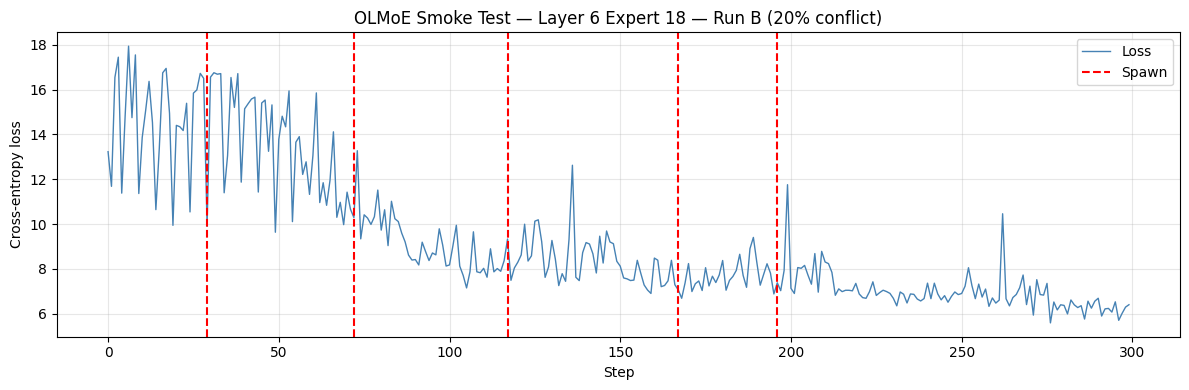

Saved: olmoe_smoke_test_loss.png


In [9]:
import matplotlib.pyplot as plt

print("=" * 55)
print("TASK 4 SMOKE TEST RESULTS")
print("=" * 55)
print()

# Check 1: Trigger fired
if check_trigger:
    print(f"✅ Check 1 — Trigger fired: YES")
    print(f"   Spawn steps: {spawn_steps}")
    print(f"   Total spawns: {len(spawn_steps)}")
else:
    print(f"❌ Check 1 — Trigger fired: NO")
    print(f"   The monitor did not fire in {N_STEPS} steps.")
    print(f"   Consider lowering delta_threshold or tau_plateau.")
    print(f"   EMA_code at end:    {monitor._ema_code}")
    print(f"   EMA_medical at end: {monitor._ema_medical}")
    if monitor._ema_code and monitor._ema_medical:
        divergence = abs(monitor._ema_medical - monitor._ema_code)
        print(f"   Current |EMA divergence|: {divergence:.4f} (threshold: {monitor.delta_threshold})")

print()

# Check 2: No crash after spawn
if check_no_crash and check_trigger:
    print(f"✅ Check 2 — Forward pass after spawn: NO CRASH")
    if check_zero_spawn is not None:
        status = "✅" if check_zero_spawn < 0.01 else "⚠️ "
        print(f"   {status} |ΔLoss| at spawn = {check_zero_spawn:.8f}  (threshold: 0.01)")
elif not check_trigger:
    print(f"⏭️  Check 2 — Forward pass after spawn: SKIPPED (trigger never fired)")
else:
    print(f"❌ Check 2 — Forward pass after spawn: CRASHED")

print()
print("NOTE: PPL numbers at 300 steps are not meaningful — not reported.")
print(f"      Total steps run: {len(loss_log)}")
print(f"      Final loss: {loss_log[-1]:.4f}" if loss_log else "")

# Loss curve
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(loss_log, color='steelblue', linewidth=1, label='Loss')
for s in spawn_steps:
    ax.axvline(x=s, color='red', linestyle='--', linewidth=1.5, label='Spawn' if s == spawn_steps[0] else None)
ax.set_xlabel('Step')
ax.set_ylabel('Cross-entropy loss')
ax.set_title(f'OLMoE Smoke Test — Layer {TARGET_LAYER} Expert {TARGET_EXPERT} — Run B (20% conflict)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('olmoe_smoke_test_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: olmoe_smoke_test_loss.png")

## Cell 10 — If Trigger Did Not Fire: Diagnostics

Run this cell only if Check 1 failed. It logs the two monitor conditions
every step so you can see which one is not being met.

In [10]:
if check_trigger:
    print("Trigger fired — no diagnostics needed. Skip this cell.")
else:
    print("Trigger did not fire. Running 100-step diagnostic trace...")
    print(f"{'Step':>5} {'Domain':>8} {'Loss':>8} {'RI_slope':>10} {'Plateau?':>9} {'|ΔEMA|':>8} {'Conflict?':>10}")
    print("-" * 70)

    # Re-patch fresh
    current = model.model.layers[TARGET_LAYER].mlp.experts
    if isinstance(current, HierarchicalOLMoEExperts):
        orig = current.original
        if hasattr(current, '_hf_hook'):
            h = current._hf_hook
            remove_hook_from_module(current)
            add_hook_to_module(orig, h)
        model.model.layers[TARGET_LAYER].mlp.experts = orig
    else:
        orig = current

    hier2 = HierarchicalOLMoEExperts(orig, base_rank=16, lora_alpha=32)
    model.model.layers[TARGET_LAYER].mlp.experts = hier2
    if hasattr(orig, '_hf_hook'):
        h = orig._hf_hook
        remove_hook_from_module(orig)
        add_hook_to_module(hier2, h)

    diag_monitor = ConflictSaturationMonitor(tau_plateau=1e-4, delta_threshold=1.0, window=15)
    diag_opt = torch.optim.AdamW([p for p in hier2.parameters() if p.requires_grad], lr=LR)
    ri_history, ema_c_hist, ema_m_hist = [], [], []

    for step in range(100):
        idx2      = step % len(texts)
        domain2   = domains[idx2]
        input_ids2 = encodings["input_ids"][idx2].unsqueeze(0)
        labels2    = input_ids2.clone()
        labels2[:, :-1] = input_ids2[:, 1:]
        labels2[:, -1]  = -100

        diag_opt.zero_grad()
        loss2 = model(input_ids=input_ids2, labels=labels2).loss
        loss2.backward()
        diag_opt.step()

        lora2 = hier2.base_loras[TARGET_EXPERT]
        diag_monitor.update(lora2.A.data, lora2.B.data, loss2.item(), domain2)

        ri = diag_monitor._ri_history[-1] if diag_monitor._ri_history else 0
        ri_history.append(ri)

        if len(diag_monitor._ri_history) >= 15:
            recent = diag_monitor._ri_history[-15:]
            x = torch.arange(15, dtype=torch.float32)
            y = torch.tensor(recent, dtype=torch.float32)
            slope = ((x*y).mean() - x.mean()*y.mean()) / (x.var(unbiased=False) + 1e-12)
            plateau = abs(slope.item()) < 1e-4
            slope_val = slope.item()
        else:
            slope_val, plateau = float('nan'), False

        ec = diag_monitor._ema_code
        em = diag_monitor._ema_medical
        delta_ema = abs(em - ec) if ec is not None and em is not None else float('nan')
        conflict  = delta_ema > 1.0 if not (delta_ema != delta_ema) else False

        if (step + 1) % 10 == 0:
            print(f"{step+1:>5} {domain2:>8} {loss2.item():>8.3f} "
                  f"{slope_val:>10.2e} {'YES' if plateau else 'NO':>9} "
                  f"{delta_ema:>8.3f} {'YES' if conflict else 'NO':>10}")

    print()
    print("Diagnosis: which condition is failing?")
    print(f"  Final |ΔEMA|: {delta_ema:.4f} (need > 1.0 for conflict)")
    print(f"  Final slope:  {slope_val:.2e} (need < 1e-4 for plateau)")
    if delta_ema < 1.0:
        print("  → Lower delta_threshold (try 0.5) OR increase conflict ratio")
    if not (slope_val != slope_val) and abs(slope_val) >= 1e-4:
        print("  → Lower tau_plateau (try 1e-3) OR run more steps before trigger")

Trigger fired — no diagnostics needed. Skip this cell.
